In [2]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from tqdm import tqdm

from scipy.optimize import brentq

ROOT = Path().resolve().parents[0]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],  # list, not string
    "font.size": 7,
})
plt.style.use('../../paper.mplstyle')

%reload_ext autoreload
%autoreload 2

cm = 1/2.54
fw = 17.8*cm
hw = 8.7*cm

In [3]:
def vk_analytical(Cx, lam, sigma_in, sigma_out, N_eff, cost=None):
    sin2  = sigma_in  ** 2
    sout2 = sigma_out ** 2

    if cost is None:
        cost = np.ones_like(Cx)

    v = np.zeros_like(Cx, dtype=float)
    mask = Cx > 0

    ratio = Cx[mask] / (Cx[mask] + sin2)

    # Temporal-derivative cost enters as a frequency-dependent multiplier
    # on the Lagrange multiplier.
    lam_eff = lam * cost[mask]

    inner = np.sqrt(
        1.0 + (sin2 / sout2) * (2.0 * N_eff) / (lam_eff * Cx[mask])
    )

    raw = (sout2 / sin2) * (ratio * 0.5 * (inner + 1.0) - 1.0)

    v[mask] = np.maximum(raw, 0.0)
    return v


def power_residual(Cx, log_lam, sigma_in, sigma_out, N_eff, weights, cost):
    lam = np.exp(log_lam)
    v   = vk_analytical(Cx, lam, sigma_in, sigma_out, N_eff, cost=cost)
    return np.sum(weights * cost * (Cx + sigma_in**2) * v) - N_eff


def Cx_separable(k, w, alpha=2.0, beta=1.3):
    Cx = 1.0 / (k[:, None]**alpha * np.maximum(w[None, :], 1e-4)**beta) 
    return Cx


def Cx_drift(sf, tf, D, alpha=2.0,signal_scale = 1e4):
    k = 2 * np.pi * sf
    w = 2 * np.pi * tf
    Dk2 = D * k[:, None]**2
    Cs  = k[:, None]**(-alpha)
    w2  = w[None, :]**2
    return signal_scale*Dk2 * Cs / (Dk2**2 + w2)


def Cx_separable_drift(sf, tf, D, alpha=2.0):
    k = 2 * np.pi * sf
    w = 2 * np.pi * tf
    Dk2 = D * k[:, None]**2
    w2  = w[None, :]**2
    C_drift = Dk2 / (Dk2**2 + w2)
    return Cx_separable(k, w, alpha=alpha) * C_drift


def brownian_probability_1d(x, D, t):
    return 1 / np.sqrt(4 * np.pi * D * t) * np.exp(-x**2 / (4 * D * t))


def one_sided_weights(n, drop_dc=False):
    """
    Degeneracy weights for np.fft.rfftfreq(n).
    Interior positive frequencies count twice.
    DC and Nyquist, if present, count once.
    """
    freqs = np.fft.rfftfreq(n)
    weights = np.ones_like(freqs)
    weights[1:] = 2.0

    if n % 2 == 0:
        weights[-1] = 1.0  # Nyquist is self-conjugate

    if drop_dc:
        freqs = freqs[1:]
        weights = weights[1:]

    return weights


def mutual_information(sf, tf, weights, D, sigma_in, sigma_out, alpha=2.0, c=0.0,separable=False):
    if separable:
        Cx = Cx_separable(sf, tf, alpha=alpha)
    else:
        Cx = Cx_drift(sf, tf, D, alpha=alpha)
    # Cx = Cx_separable_drift(k, w, D, alpha=alpha)
    # Cx = Cx / np.sum(Cx * weights)

    N_eff = np.sum(weights)

    # Temporal derivative cost: a(w) = 1 + c w^2
    cost = 1.0 + c * tf[None, :]**2
    cost = np.broadcast_to(cost, Cx.shape)

    pr = lambda log_lam: power_residual(
        Cx, log_lam, sigma_in, sigma_out, N_eff, weights, cost
    )

    log_lam_opt = brentq(pr, -50.0, 50.0, xtol=1e-12)

    v_opt = vk_analytical(
        Cx, np.exp(log_lam_opt), sigma_in, sigma_out, N_eff, cost=cost
    )

    noise_floor = sigma_in**2 * v_opt + sigma_out**2
    snr = Cx * v_opt / noise_floor

    MI = 0.5 * np.sum(weights * np.log1p(snr))
    return Cx, v_opt, MI


def minimum_phase_rfft_from_magnitude(amp, axis=-1, eps=1e-12):
    """Minimum-phase spectrum from |H| on an rfft-ordered temporal axis."""
    amp = np.maximum(np.asarray(amp, dtype=float), eps)
    log_amp = np.log(amp)

    # Real cepstrum of log-amplitude (Hilbert transform in log-frequency domain).
    cep = np.fft.irfft(log_amp, axis=axis).real

    n = amp.shape[axis]
    cep_min = np.zeros_like(cep)
    idx = [slice(None)] * amp.ndim
    idx[axis] = 0
    cep_min[tuple(idx)] = cep[tuple(idx)]

    if n % 2 == 0:
        idx_pos = list(idx)
        idx_pos[axis] = slice(1, n // 2)
        cep_min[tuple(idx_pos)] = 2.0 * cep[tuple(idx_pos)]
        idx_nyq = list(idx)
        idx_nyq[axis] = n // 2
        cep_min[tuple(idx_nyq)] = cep[tuple(idx_nyq)]
    else:
        idx_pos = list(idx)
        idx_pos[axis] = slice(1, (n + 1) // 2)
        cep_min[tuple(idx_pos)] = 2.0 * cep[tuple(idx_pos)]

    log_H = np.fft.fft(cep_min, axis=axis)
    return np.exp(log_H)


def compute_space_time_filter(v_opt, T, dt, dx):
    # Magnitude from power; temporal phase comes from the minimum-phase construction.
    amp = np.sqrt(np.maximum(v_opt, 0.0))
    # amp[:,0] = 0
    floor = 1e-3 * max(float(np.nanmax(amp)), 1e-300)
    amp = np.maximum(amp, floor)

    # Minimum phase in time, independently at each positive spatial frequency.
    H_k_w = minimum_phase_rfft_from_magnitude(amp, axis=1)

    # Zero phase in space: mirror positive k to negative k with the same complex spectrum.
    H_spatial_centered = np.concatenate([H_k_w[::-1, :], H_k_w], axis=0)  # (K, len(w))

    # Spatial axis to DFT order, then inverse FFT over time and space.
    H = np.fft.ifftshift(H_spatial_centered, axes=0)
    w_xt = np.fft.ifft(np.fft.irfft(H, n=T, axis=1), axis=0).real  # (K, T)

    # Center space for plotting; keep time causal (no fftshift in time).
    w_xt_plot = np.fft.fftshift(w_xt, axes=0)
    x = (np.arange(K) - K // 2) * dx
    t = np.arange(T) * dt
    return w_xt_plot, x, t

def plot_contours(ax,x,y,z,levels,lw=1,cmap="magma"):
    c = ax.contourf(
        x, y, z.T, levels=levels, cmap=cmap, extend="both"
    )
    ax.contour(
        x, y, z.T, levels=levels, colors="k", linewidths=lw, linestyles="solid", negative_linestyle="solid"
    )
    return c 


In [4]:
d=np.load("../data/subpixel_power_spectrum.npz")
power,sf,tf=d["power"],d["sf"],d["tf"]

D_arcmin = 40
D_deg = D_arcmin / 60.0**2
sigma_in  = 0.2
sigma_out = 2.0
K         = 256
T         = 4000
alpha     = 2.0
temporal_cost = 0.1

dt = 1.0 / (T * (tf[1] - tf[0]))
dx = 1.0 / (K * (sf[1] - sf[0]))

wk = np.full(len(sf), 2.0)
ww = one_sided_weights(T, drop_dc=False)[:-1]

print(f"min,max temporal frequency: {tf.min():.2f}, {tf.max():.2f}")
print(f"min,max spatial frequency: {sf.min():.2f}, {sf.max():.2f}")

weights = wk[:, None] * ww[None, :]
N_eff = np.sum(weights)

min,max temporal frequency: 0.00, 99.95
min,max spatial frequency: 0.12, 29.88


<>:66: SyntaxWarning: invalid escape sequence '\s'
<>:66: SyntaxWarning: invalid escape sequence '\s'
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_25744/2307108078.py:66: SyntaxWarning: invalid escape sequence '\s'
  ax.text(D_arcmins[np.argmax(MI_vals)], np.max(MI_vals)+7e2, f'$\sigma_{{in}} = {sigma_ins_sweep[i]:.2g}$',horizontalalignment="center")
9it [01:00,  6.77s/it]


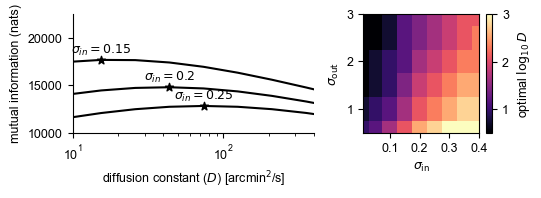

In [4]:
def sweep_noise():

    all_MI_vals = []
    v_opt_list = []
    sigma_ins_sweep = np.arange(0.0,0.41,0.05)
    sigma_ins_sweep[0] = 0.01
    sigma_outs_sweep = np.arange(0.0,3.5,0.5)
    sigma_outs_sweep[0] = 0.5

    D_arcmins = np.logspace(-1.3, 3, 20)

    D_opt = []
    for i, sigma_in in tqdm(enumerate(sigma_ins_sweep)):
        for sigma_out in sigma_outs_sweep:
            MI_vals = []
            v_opts = []
            for j, D_arcmin in enumerate(D_arcmins):

                D_deg = D_arcmin / 60.0**2
                Cx, v_opt, MI = mutual_information(
                    sf,
                    tf,
                    weights,
                    D_deg,
                    sigma_in,
                    sigma_out,
                    alpha,
                    c=temporal_cost
                )
                MI_vals.append(MI)
                v_opts.append(v_opt)
            best_idx = np.argmax(MI_vals)
            D_opt.append(D_arcmins[best_idx])
            v_opt_list.append(v_opts[best_idx])
            all_MI_vals.append(MI_vals)

    # Shape: (n_sigma_in, n_sigma_out, n_D)
    all_MI_arr = np.asarray(all_MI_vals).reshape(
        len(sigma_ins_sweep), len(sigma_outs_sweep), len(D_arcmins)
    )

    fig, axs = plt.subplots(1, 2, figsize=(0.8 * fw, 0.6 * hw), width_ratios=[1, 0.6])
    ax = axs[0]

    # MI vs D for three fixed input-noise models, at fixed output noise.
    sigma_out_fixed = 2.0
    j_out = int(np.argmin(np.abs(sigma_outs_sweep - sigma_out_fixed)))
    input_noise_to_plot = [3, 4, 5]  # indices into sigma_ins_sweep

    for color_i, i in enumerate(input_noise_to_plot):
        MI_vals = all_MI_arr[i, j_out]
        color = "k"
        ax.plot(
            D_arcmins,
            MI_vals,
            label=rf"$\sigma_{{\mathrm{{in}}}}={sigma_ins_sweep[i]:.2g}$",
            color=color,
        )
        ax.scatter(
            D_arcmins[np.argmax(MI_vals)],
            np.max(MI_vals),
            marker="*",
            color=color,
            zorder=3,
        )
        ax.text(D_arcmins[np.argmax(MI_vals)], np.max(MI_vals)+7e2, f'$\sigma_{{in}} = {sigma_ins_sweep[i]:.2g}$',horizontalalignment="center")

    ax.set_xlabel(r"diffusion constant ($D$) [arcmin$^2$/s]")
    ax.set_ylabel("mutual information (nats)")
    ax.set_xscale("log")
    ax.set_xlim(10,400)
    ax.set_ylim(1e4,2.25e4)

    D_opt_arr = np.array(D_opt).reshape(len(sigma_ins_sweep), len(sigma_outs_sweep))

    ax = axs[1]
    # pcolormesh wants Z shaped (len(y), len(x)) when X,Y are 1D centers with shading='nearest'
    pcm = ax.pcolormesh(
        sigma_ins_sweep,
        sigma_outs_sweep,
        np.log10(D_opt_arr.T),
        shading="nearest",
        cmap="magma",
    )
    cbar = plt.colorbar(pcm, ax=ax, label=r"optimal $\log_{10} D$")

    # ax.set_xscale("log")
    # ax.set_yscale("log")
    ax.set_xlabel(r"$\sigma_{\mathrm{in}}$")
    ax.set_ylabel(r"$\sigma_{\mathrm{out}}$")
    ax.set_xticks([0.1, 0.2, 0.3, 0.4])
    ax.set_xlim([sigma_ins_sweep[0],sigma_ins_sweep[-1]])
    ax.set_ylim([sigma_outs_sweep[0],sigma_outs_sweep[-1]])
    ax.set_yticks([ 1, 2, 3])
    ax.get_xaxis().set_major_formatter(ScalarFormatter())
    ax.get_yaxis().set_major_formatter(ScalarFormatter())
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(True)


    plt.tight_layout()
    plt.savefig("../results/optimal_diffusion_constant_vs_input_output_noise.pdf")

sweep_noise()

In [5]:
Cx, v_opt, MI = mutual_information(
    sf, 
    tf, 
    weights, 
    D_deg, 
    sigma_in, 
    sigma_out, 
    alpha,
    c=temporal_cost
)

<>:72: SyntaxWarning: invalid escape sequence '\l'
<>:72: SyntaxWarning: invalid escape sequence '\l'
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_26163/1727594645.py:72: SyntaxWarning: invalid escape sequence '\l'
  ax_temporal.set(xscale="log", xlabel="Temporal frequency (Hz)", ylabel="$\log_{10}(\mathrm{power})$",)
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_26163/560354938.py:168: UserWarning: The following kwargs were not used by contour: 'negative_linestyle'
  ax.contour(


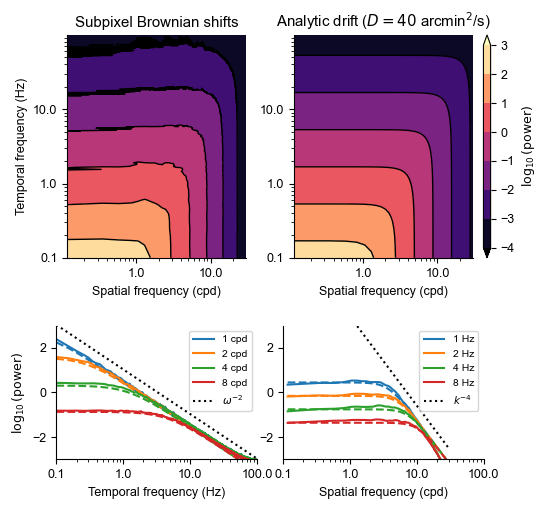

In [15]:
ylim = [0.1,100]
xlim = [0.1,100]

if power.shape == (len(tf), len(sf)):
    power = power.T
if power.shape != (len(sf), len(tf)):
    raise ValueError(power.shape)

sf_targets = [1, 2, 4, 8]
tf_targets = [1, 2, 4, 8]
sf_mask = sf > 0
tf_mask = tf >= 0.1
sf_plot = sf[sf_mask]
tf_plot = tf[tf_mask]

plot_subpix = np.log10(np.clip(power, 1e-12, None))[np.ix_(sf_mask, tf_mask)]
plot_analytic = np.log10(np.clip(Cx_drift(sf, tf, D_deg, alpha=2.0), 1e-12, None))[
    np.ix_(sf_mask, tf_mask)
]
# Match the empirical normalization (overall multiplicative gain in linear power).
offset = np.nanmedian(plot_analytic - plot_subpix)
plot_subpix = plot_subpix + offset

levels = np.arange(
    np.floor(np.nanmin([plot_subpix.min(), plot_analytic.min()])),
    np.ceil(np.nanmax([plot_subpix.max(), plot_analytic.max()])) + 1,
)

fig = plt.figure(figsize=(14*cm, 14*cm))
g = fig.add_gridspec(2, 4, height_ratios=[1, 0.6], hspace=0.38, wspace=0.3)

ax_emp = fig.add_subplot(g[0, :2])
c_emp = plot_contours(ax_emp, sf_plot, tf_plot, plot_subpix, levels)

ax_analytic = fig.add_subplot(g[0, 2:], sharey=ax_emp)
c_analytic = plot_contours(ax_analytic, sf_plot, tf_plot, plot_analytic, levels)


for ax, title in [
    (ax_emp, "Subpixel Brownian shifts"),
    (ax_analytic, rf"Analytic drift ($D={D_arcmin}$ arcmin$^2$/s)"),
]:
    ax.set(
        xscale="log",
        yscale="log",
        xlabel="Spatial frequency (cpd)",
        title=title,
    )
    ax.set_aspect("equal", adjustable="box")
ax_emp.set_ylabel("Temporal frequency (Hz)")

ax_temporal = fig.add_subplot(g[1, :2])
for target in sf_targets:
    i = np.argmin(np.abs(sf_plot - target))
    line = ax_temporal.plot(tf_plot, plot_subpix[i], label=f"{sf_plot[i]:.1g} cpd")[0]
    ax_temporal.plot(tf_plot, plot_analytic[i], "--", color=line.get_color())

a = np.argmin(np.abs(tf_plot - 2))
p = max(plot_subpix[np.argmin(np.abs(sf_plot - t)), a] for t in sf_targets) + 0.5
ax_temporal.plot(tf_plot, p - 2 * np.log10(tf_plot / tf_plot[a]), "k:",  label=r"$\omega^{-2}$")

ax_spatial = fig.add_subplot(g[1, 2:], sharey=ax_temporal)
for target in tf_targets:
    i = np.argmin(np.abs(tf_plot - target))
    line = ax_spatial.plot(sf_plot, plot_subpix[:, i],  label=f"{tf_plot[i]:.1g} Hz")[0]
    ax_spatial.plot(sf_plot, plot_analytic[:, i], "--", color=line.get_color())

a = np.argmin(np.abs(sf_plot - 2))
p = max(plot_subpix[a, np.argmin(np.abs(tf_plot - t))] for t in tf_targets) + 1.75
ax_spatial.plot(sf_plot, p - 4 * np.log10(sf_plot / sf_plot[a]), "k:", label=r"$k^{-4}$")

ax_temporal.set(xscale="log", xlabel="Temporal frequency (Hz)", ylabel="$\log_{10}(\mathrm{power})$",)
ax_spatial.set(xscale="log", xlabel="Spatial frequency (cpd)", )
# ax_temporal.set_box_aspect(1)
# ax_spatial.set_box_aspect(1)
ax_temporal.legend(fontsize="small")
ax_spatial.legend(fontsize="small")
ax_temporal.set_xlim(ylim)
ax_spatial.set_xlim(xlim)

f = ScalarFormatter()
f.set_scientific(False)
f.set_useOffset(False)
for ax in [ax_emp, ax_analytic, ax_temporal, ax_spatial]:
    ax.xaxis.set_major_formatter(f)
for ax in [ax_emp, ax_analytic]:
    ax.yaxis.set_major_formatter(f)
for ax in [ax_temporal, ax_spatial]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim([-3,3])

cax = inset_axes(
    ax_analytic,
    width="4%",
    height="100%",
    loc="lower left",
    bbox_to_anchor=(1.06, 0, 1, 1),
    bbox_transform=ax_analytic.transAxes,
    borderpad=0,
)
fig.colorbar(c_emp, cax=cax, label=r"$\log_{10}(\mathrm{power})$")
plt.savefig("../results/emp_vs_analytic.pdf")


<>:55: SyntaxWarning: invalid escape sequence '\l'
<>:55: SyntaxWarning: invalid escape sequence '\l'
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_25744/3941947601.py:55: SyntaxWarning: invalid escape sequence '\l'
  ylabel="$\log_{10}(\mathrm{power})$",
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_25744/560354938.py:168: UserWarning: The following kwargs were not used by contour: 'negative_linestyle'
  ax.contour(


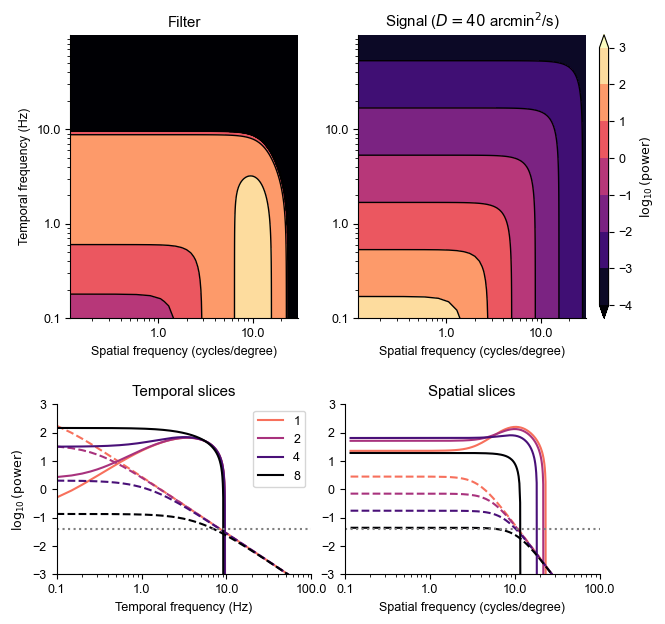

In [ ]:
plot_filter = np.log10(np.clip(v_opt, 1e-12, None))[np.ix_(sf_mask, tf_mask)]

levels = np.arange(
    np.floor(np.nanmin([plot_subpix.min(), plot_analytic.min()])),
    np.ceil(np.nanmax([plot_subpix.max(), plot_analytic.max()])) + 1,
)
filter_levels = np.arange(
    np.floor(np.nanmin([plot_filter.min()])),
    np.ceil(np.nanmax([plot_filter.max()])) + 1,
)
filter_levels = levels# np.arange(-1,5)

fig = plt.figure(figsize=(fw, fw))
g = fig.add_gridspec(2, 4, height_ratios=[1, 0.6], hspace=0.38, wspace=0.3)

ax_analytic = fig.add_subplot(g[0, 2:])
c_analytic = plot_contours(ax_analytic, sf_plot, tf_plot, plot_analytic, levels)


ax_filter = fig.add_subplot(g[0, :2], sharey=ax_analytic)
c_filter = plot_contours(ax_filter, sf_plot, tf_plot, plot_filter, filter_levels)


for ax, title in [
    (ax_filter, "Filter"),
    (ax_analytic, rf"Signal ($D={D_arcmin}$ arcmin$^2$/s)"),
]:
    ax.set(
        xscale="log",
        yscale="log",
        xlabel="Spatial frequency (cycles/degree)",
        title=title,
    )
    ax.set_aspect("equal", adjustable="box")
ax_filter.set_ylabel("Temporal frequency (Hz)")

colors = mpl.cm.magma_r(np.linspace(0.3, 1, len(sf_targets)))
ax_temporal = fig.add_subplot(g[1, :2])
for j,target in enumerate(sf_targets):
    i = np.argmin(np.abs(sf_plot - target))
    line = ax_temporal.plot(tf_plot, plot_filter[i], label=f"{sf_plot[i]:.1g}", color=colors[j])[0]
    ax_temporal.plot(tf_plot, plot_analytic[i], "--", color=line.get_color())

colors = mpl.cm.magma_r(np.linspace(0.3, 1, len(tf_targets)))
ax_spatial = fig.add_subplot(g[1, 2:], sharey=ax_temporal)
for j,target in enumerate(tf_targets):
    i = np.argmin(np.abs(tf_plot - target))
    line = ax_spatial.plot(sf_plot, plot_filter[:, i], label=f"{tf_plot[i]:.1g}", color=colors[j])[0]
    ax_spatial.plot(sf_plot, plot_analytic[:, i], "--", color=line.get_color())


ax_temporal.set(
    xscale="log", 
    xlabel="Temporal frequency (Hz)", 
    ylabel="$\log_{10}(\mathrm{power})$", 
    title="Temporal slices"
)
ax_spatial.set(
    xscale="log", 
    xlabel="Spatial frequency (cycles/degree)", 
    # ylabel="$\log_{10}(\mathrm{power})$", 
    title="Spatial slices"
)
# ax_temporal.set_box_aspect(1)
# ax_spatial.set_box_aspect(1)
ax_temporal.legend()
# ax_spatial.legend()
ax_temporal.set_xlim(ylim)
ax_spatial.set_xlim(xlim)

f = ScalarFormatter()
f.set_scientific(False)
f.set_useOffset(False)
for ax in [ax_filter, ax_analytic, ax_temporal, ax_spatial]:
    ax.xaxis.set_major_formatter(f)
for ax in [ax_filter, ax_analytic]:
    ax.yaxis.set_major_formatter(f)
for ax in [ax_temporal, ax_spatial]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.axhline(np.log10(sigma_in**2),color="grey",linestyle=":")
    ax.set_ylim([-3,3])

cax = inset_axes(
    ax_analytic,
    width="4%",
    height="100%",
    loc="lower left",
    bbox_to_anchor=(1.06, 0, 1, 1),
    bbox_transform=ax_analytic.transAxes,
    borderpad=0,
)
fig.colorbar(c_analytic, cax=cax, label=r"$\log_{10}(\mathrm{power})$")
# cax = inset_axes(
#     ax_filter,
#     width="4%",
#     height="100%",
#     loc="lower left",
#     bbox_to_anchor=(1.06, 0, 1, 1),
#     bbox_transform=ax_filter.transAxes,
#     borderpad=0,
# )
# fig.colorbar(c_filter, cax=cax, label=r"$\log_{10}(\mathrm{power})$")



<>:90: SyntaxWarning: invalid escape sequence '\l'
<>:90: SyntaxWarning: invalid escape sequence '\l'
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_26163/1225019997.py:90: SyntaxWarning: invalid escape sequence '\l'
  ylabel="$\log_{10}(\mathrm{power})$",
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_26163/560354938.py:168: UserWarning: The following kwargs were not used by contour: 'negative_linestyle'
  ax.contour(
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_26163/1225019997.py:127: UserWarning: Adding colorbar to a different Figure <Figure size 700.787x700.787 with 6 Axes> than <Figure size 700.787x342.52 with 7 Axes> which fig.colorbar is called on.
  fig.colorbar(c_analytic, cax=cax, label=r"$\log_{10}(\mathrm{power})$")


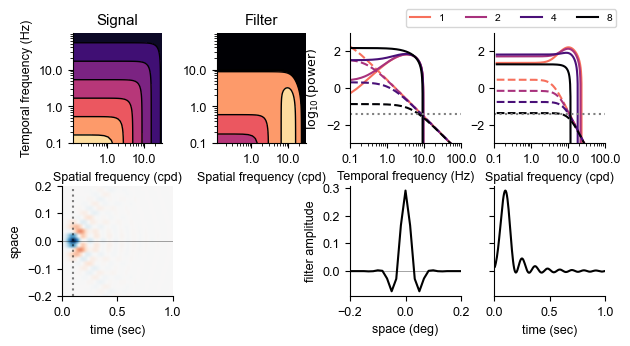

In [8]:
plot_filter = np.log10(np.clip(v_opt, 1e-12, None))[np.ix_(sf_mask, tf_mask)]

max_time = 1.
max_space = 0.2

levels = np.arange(
    np.floor(np.nanmin([plot_subpix.min(), plot_analytic.min()])),
    np.ceil(np.nanmax([plot_subpix.max(), plot_analytic.max()])) + 1,
)
filter_levels = np.arange(
    np.floor(np.nanmin([plot_filter.min()])),
    np.ceil(np.nanmax([plot_filter.max()])) + 1,
)
filter_levels = levels # np.arange(-1,5)

fig = plt.figure(figsize=(fw, hw))
g = fig.add_gridspec(2, 4, hspace=0.38, wspace=0.3)

ax_signal = fig.add_subplot(g[0,0])
c_signal = plot_contours(ax_signal, sf_plot, tf_plot, plot_analytic, levels)

ax_filter = fig.add_subplot(g[0,1],sharey=ax_signal)
c_filter = plot_contours(ax_filter, sf_plot, tf_plot, plot_filter, filter_levels)


w_xt_plot, x, t = compute_space_time_filter(v_opt, T, dt, dx)
ax_kernel = fig.add_subplot(g[1,:1])
vmag = np.abs(w_xt_plot).max()
im = ax_kernel.imshow(w_xt_plot, aspect="auto", origin="lower", extent=[t[0], t[-1], x[0], x[-1]], cmap="RdBu", vmin=-vmag, vmax=vmag)
ax_kernel.set_xlabel("time (sec)")
ax_kernel.set_ylabel("space")
ax_kernel.set_xlim([0, max_time])
ax_kernel.set_ylim([-max_space, max_space])


ax_spatial_slice = fig.add_subplot(g[1, 2])
arg_slice = w_xt_plot[w_xt_plot.shape[0] // 2, :].argmax()
plot_slices = [arg_slice, ]
for s in plot_slices:
    spatial_slice = w_xt_plot[:, s]
    ax_kernel.axvline(t[s], color="k", alpha=0.5, linestyle=":")
    ax_spatial_slice.plot(x, spatial_slice,c="k")
ax_spatial_slice.axhline(0, color="k", alpha=0.5, linewidth=0.5)
ax_spatial_slice.set_xlim([-max_space, max_space])
ax_spatial_slice.set_xlabel("space (deg)")
ax_spatial_slice.set_ylabel("filter amplitude")
ymin, ymax = ax_spatial_slice.get_ylim()

# row 1, col 5: temporal slice
ax_temporal_slice = fig.add_subplot(g[1, 3])
ax_temporal_slice.plot(t, w_xt_plot[w_xt_plot.shape[0] // 2, :],c="k")
ax_temporal_slice.set_xlabel("time (sec)")
ax_temporal_slice.set_xlim([0, max_time])
ax_temporal_slice.set_ylim([ymin,ymax])
ax_temporal_slice.set_yticklabels([])
ax_kernel.axhline(0, color="k", alpha=0.5, linewidth=0.5)


for ax, title in [
    (ax_filter, "Filter"),
    (ax_signal, "Signal")
]:
    ax.set(
        xscale="log",
        yscale="log",
        xlabel="Spatial frequency (cpd)",
        title=title,
    )
    ax.set_aspect("equal", adjustable="box")
ax_signal.set_ylabel("Temporal frequency (Hz)")

colors = mpl.cm.magma_r(np.linspace(0.3, 1, len(sf_targets)))
ax_temporal = fig.add_subplot(g[0,2])
for j,target in enumerate(sf_targets):
    i = np.argmin(np.abs(sf_plot - target))
    line = ax_temporal.plot(tf_plot, plot_filter[i], label=f"{sf_plot[i]:.1g}", color=colors[j])[0]
    ax_temporal.plot(tf_plot, plot_analytic[i], "--", color=line.get_color())

colors = mpl.cm.magma_r(np.linspace(0.3, 1, len(tf_targets)))
ax_spatial = fig.add_subplot(g[0,3], sharey=ax_temporal)
for j,target in enumerate(tf_targets):
    i = np.argmin(np.abs(tf_plot - target))
    line = ax_spatial.plot(sf_plot, plot_filter[:, i], label=f"{tf_plot[i]:.1g}", color=colors[j])[0]
    ax_spatial.plot(sf_plot, plot_analytic[:, i], "--", color=line.get_color())


ax_temporal.set(
    xscale="log", 
    xlabel="Temporal frequency (Hz)", 
    ylabel="$\log_{10}(\mathrm{power})$", 
    # title="Temporal slices"
)
ax_spatial.set(
    xscale="log", 
    xlabel="Spatial frequency (cpd)", 
    # ylabel="$\log_{10}(\mathrm{power})$", 
    # title="Spatial slices"
)

# ax_temporal.legend()
ax_temporal.legend(fontsize="small", ncol=4, loc=(0.5,1.05))
ax_temporal.set_xlim(ylim)
ax_spatial.set_xlim(xlim)

f = ScalarFormatter()
f.set_scientific(False)
f.set_useOffset(False)
for ax in [ax_filter, ax_temporal, ax_spatial,ax_signal]:
    ax.xaxis.set_major_formatter(f)
for ax in [ax_filter,ax_signal]:
    ax.yaxis.set_major_formatter(f)
for ax in [ax_temporal, ax_spatial]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.axhline(np.log10(sigma_in**2),color="grey",linestyle=":")
    ax.set_ylim([-3,3])

cax = inset_axes(
    ax_analytic,
    width="4%",
    height="100%",
    loc="lower left",
    bbox_to_anchor=(1.06, 0, 1, 1),
    bbox_transform=ax_analytic.transAxes,
    borderpad=0,
)
fig.colorbar(c_analytic, cax=cax, label=r"$\log_{10}(\mathrm{power})$")
plt.savefig("../results/optimal_filter.pdf")


/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_25744/560354938.py:57: RuntimeWarning: divide by zero encountered in divide
  return 1 / np.sqrt(4 * np.pi * D * t) * np.exp(-x**2 / (4 * D * t))
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_25744/560354938.py:57: RuntimeWarning: invalid value encountered in multiply
  return 1 / np.sqrt(4 * np.pi * D * t) * np.exp(-x**2 / (4 * D * t))
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_25744/537189392.py:30: RuntimeWarning: divide by zero encountered in log10
  z = np.ma.masked_where(rho <= 0, np.log10(rho))
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_25744/560354938.py:168: UserWarning: The following kwargs were not used by contour: 'negative_linestyle'
  ax.contour(
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_25744/560354938.py:168: UserWarning: The following kwargs were not used by contour: 'negative_linestyle'
  ax.contour(
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/

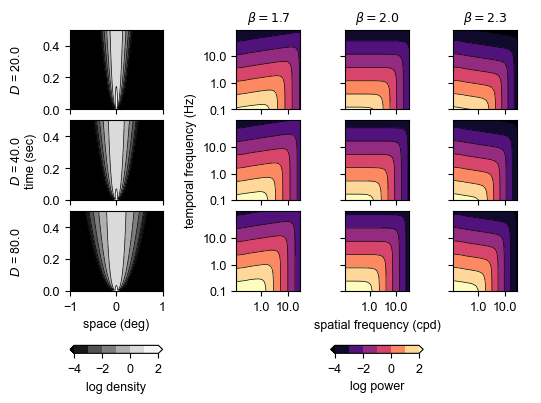

In [9]:
def plot_matrix():

    betas = [1.7, 2.0, 2.3]
    D_arcmins = [20,40,80]

    ncols = 2 + len(betas)
    nrows = len(D_arcmins)
    spec_mid_col = 2 + len(betas) // 2

    fig = plt.figure(figsize=(0.85*fw, 0.6 * fw))
    gs = fig.add_gridspec(
        nrows + 2,
        ncols,
        height_ratios=[1] * nrows + [0.4]+[0.1],
        width_ratios=[1] + [0.3] + [1] * len(betas),
    )

    levels = np.arange(-4, 3, 1)
    cf = None
    rho_cax = None
    for j, D_arcmin in enumerate(D_arcmins):
        D_deg = D_arcmin / 60.0**2

        # --- left column: displacement density ---
        ax = fig.add_subplot(gs[j, 0])
        x = np.linspace(-1, 1, 500)
        t = np.linspace(0, 0.5, 100)
        rho = brownian_probability_1d(x[:, None], D_deg, t[None, :])
        ax.set_facecolor("black")
        z = np.ma.masked_where(rho <= 0, np.log10(rho))
        rho_cax = plot_contours(ax,x,t,z,levels,lw=0.5,cmap="Greys_r")

        ax.spines["right"].set_visible(True)
        ax.spines["top"].set_visible(True)
        if j == nrows - 1:
            ax.set_xlabel("space (deg)")
        else:
            ax.set_xticklabels([])
            ax.set_xlabel("")
        ax.set_xlim(x.min(), x.max())
        ax.set_ylim(t.min(), t.max())
        if j == 1:
            ax.set_ylabel(rf"$D$ = {D_arcmin:.1f}" + "\n" + r"time (sec)")
        else:
            ax.set_ylabel(rf"$D$ = {D_arcmin:.1f}" + "\n")

        # --- SF/TF spectrum matrix ---
        for i, beta in enumerate(betas):
            
            plot_analytic = np.log10(np.clip(Cx_drift(sf, tf, D_deg, alpha=beta), 1e-12, None))[
                np.ix_(sf_mask, tf_mask)
            ]
            ax = fig.add_subplot(gs[j, i + 2])
            cf = plot_contours(ax, sf_plot, tf_plot, plot_analytic, levels,lw=0.5)
            
            ax.spines["right"].set_visible(True)
            ax.spines["top"].set_visible(True)
            ax.set_xscale("log")
            ax.set_yscale("log")
            ax.minorticks_off()
            for axis in (ax.xaxis, ax.yaxis):
                fmt = ScalarFormatter()
                fmt.set_scientific(False)
                fmt.set_useOffset(False)
                # axis.set_major_formatter(fmt)
            ax.xaxis.set_major_formatter(f)
            ax.yaxis.set_major_formatter(f)
            # ax.set_xlim(0.1, s.max())
            # ax.set_ylim(0.1, w_plot.max())
            if j == 0:
                ax.set_title(f"$\\beta = {beta:.1f}$", fontsize=9)
            if j != nrows - 1:
                ax.set_xticklabels([])
            if i != 0:
                ax.set_yticklabels([])
                ax.set_ylabel("")
            elif j == 1:
                ax.set_ylabel("temporal frequency (Hz)")
            ax.set_aspect("equal")
            if j == nrows - 1 and i == len(betas) // 2:
                ax.set_xlabel("spatial frequency (cpd)")

    # colorbars in bottom row: under displacement and middle spectrum column
    for col in range(ncols):
        if col not in (0, spec_mid_col):
            fig.add_subplot(gs[nrows, col]).set_axis_off()

    ax_cbar_rho = fig.add_subplot(gs[-1, 0])
    cbar_rho = fig.colorbar(
        rho_cax,
        cax=ax_cbar_rho,
        orientation="horizontal",
        label=r"log density",
    )
    ticks = cbar_rho.ax.get_xticks()
    cbar_rho.ax.set_xticks(ticks[::2] if len(ticks) > 2 else ticks)

    ax_cbar_cf = fig.add_subplot(gs[-1, spec_mid_col])
    cbar_cf = fig.colorbar(
        cf,
        cax=ax_cbar_cf,
        orientation="horizontal",
        label=r"log power",
    )
    ticks = cbar_cf.ax.get_xticks()
    cbar_cf.ax.set_xticks(ticks[::2] if len(ticks) > 2 else ticks)

    # plt.tight_layout()
    plt.savefig("../results/spatial_temporal_spectra_for_different_betas.pdf")

plot_matrix()